<a href="https://colab.research.google.com/github/carolineb3/Earnings-Call-NLP-Pipeline/blob/main/notebooks/08_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 8: Machine Learning Models

This notebook trains the main PySpark MLlib classification models using the feature matrix from Step 7. The goal is to test whether the engineered language, topic, lag, trend, and sector-control features can predict the direction of the post-earnings return label.

The split is temporal rather than random: earlier years are used for training, and the most recent year is held out as the test set. This better matches the real forecasting setup and helps avoid look-ahead bias.

## What this notebook does

- Reads `584_earnings_features.parquet` from Step 7.
- Encodes the positive/negative return label for Spark MLlib.
- One-hot encodes sector using training years only.
- Builds the final feature vector from scaled numeric features plus sector controls.
- Trains Logistic Regression, Random Forest, and Gradient Boosted Trees models.
- Compares model performance against a naive majority-class baseline.
- Builds a simple majority-vote ensemble across the three models.
- Saves model predictions as `584_earnings_ml_results.parquet`.

## Models

- Logistic Regression
- Random Forest
- Gradient Boosted Trees
- Majority-vote ensemble

## Output

- `584_earnings_ml_results.parquet`

The output includes each transcript’s ticker, quarter, actual return label, model predictions, and language-based risk score.

## Notes

- `TRAIN_YEARS = all_years[:-1]`
- `TEST_YEARS = [all_years[-1]]`
- Sector one-hot encoding is fit only on the training years.
- AUC is compared against the random-classifier benchmark of 0.50.
- The majority-class baseline is used as a simple reference point, not as a hard guarantee that the models will outperform it.

Mounted at /content/drive
Loaded feature matrix:
+------+---------+-------------+-------------+------------+----------+
|ticker|  quarter|earnings_date|pct_return_3d|return_label|risk_score|
+------+---------+-------------+-------------+------------+----------+
|     A|Q2_FY2021|   2021-05-25|       3.6779|    positive|    0.1623|
|     A|Q3_FY2021|   2021-08-17|        4.487|    positive|    0.1869|
|     A|Q4_FY2021|   2021-11-22|      -6.5794|    negative|    0.1939|
|     A|Q1_FY2022|   2022-02-22|        2.483|    positive|    0.1754|
|     A|Q3_FY2022|   2022-08-16|       3.6529|    positive|    0.1934|
|     A|Q4_FY2022|   2022-11-21|       8.1439|    positive|    0.1809|
|     A|Q1_FY2023|   2023-02-28|       1.3806|    negative|    0.1579|
|     A|Q2_FY2023|   2023-05-23|      -6.3899|    negative|    0.2902|
|     A|Q3_FY2023|   2023-08-15|      -5.0935|    negative|     0.353|
|     A|Q4_FY2023|   2023-11-20|      11.0897|    positive|    0.3259|
|     A|Q1_FY2024|   2024-02

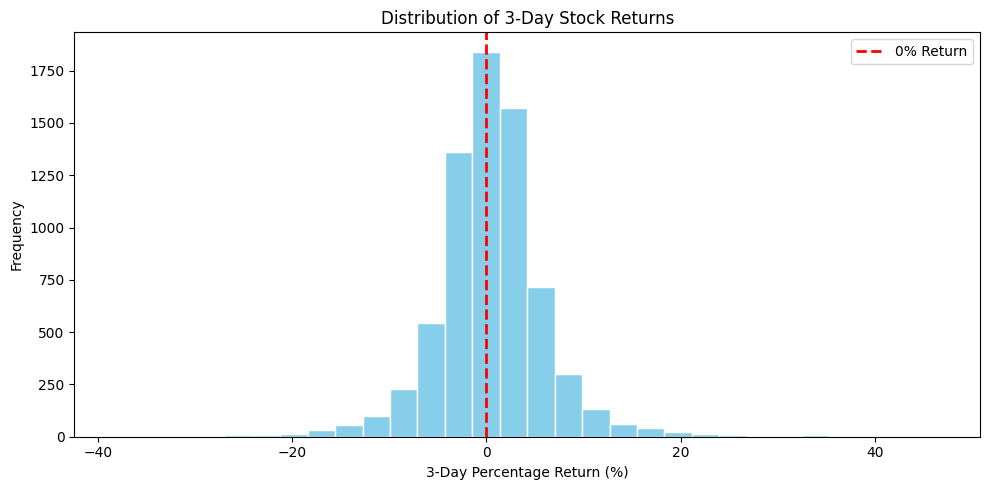

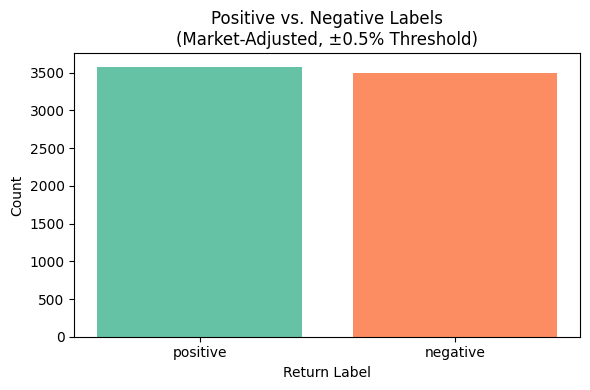

Spark session stopped.


In [ ]:
# =============================================================================
# STEP 8 — Machine Learning Models
# Train and evaluate PySpark MLlib classifiers using the engineered feature set.
# =============================================================================

!pip install pyspark

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR    = "/content/drive/MyDrive/MIS_584_Project"
PARQUET_IN  = f"{BASE_DIR}/Parquet/584_earnings_features"
PARQUET_OUT = f"{BASE_DIR}/Parquet/584_earnings_ml_results"

# Numeric scaled features from Step 7
FEATURE_COLS_SCALED = [
    # LM dictionary — prepared remarks
    'prep_net_sentiment_scaled',
    'prep_negative_score_scaled',
    'prep_uncertainty_score_scaled',
    'prep_litigious_score_scaled',
    # LM dictionary — Q&A
    'qa_net_sentiment_scaled',
    'qa_negative_score_scaled',
    'qa_uncertainty_score_scaled',
    'qa_litigious_score_scaled',
    # Cross-section divergence
    'sentiment_divergence_scaled',
    'uncertainty_divergence_scaled',
    'tone_inconsistency_scaled',
    # Topic modeling
    'qa_topic_shift_scaled',
    'qa_topic_2_prob_scaled',
    'qa_topic_3_prob_scaled',
    # Seasonality
    'quarter_num_scaled',
    # FinBERT sentiment
    'prep_finbert_positive_scaled',
    'prep_finbert_negative_scaled',
    'qa_finbert_positive_scaled',
    'qa_finbert_negative_scaled',
    'finbert_divergence_scaled',
    # # Sector is one-hot encoded later, not included in this numeric list
    # Lag and trend features
    'prev_prep_net_sentiment_scaled',
    'prev_qa_negative_score_scaled',
    'prev_finbert_negative_scaled',
    'sentiment_trend_scaled',
    'negativity_trend_scaled',
]

import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--driver-memory 8g pyspark-shell'

from pyspark.sql import SparkSession

# Start a new Spark session for this notebook
_active = SparkSession.getActiveSession()
if _active is not None:
    _active.stop()

spark = SparkSession.builder \
    .master("local") \
    .appName("584_ML_Models") \
    .config("spark.driver.maxResultSize", "0") \
    .getOrCreate()

sc = spark.sparkContext

from pyspark.ml.feature import VectorAssembler, StringIndexer, IndexToString, OneHotEncoder
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
)
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.sql import functions as F
import pandas as pd
import numpy as np

df = spark.read.parquet(PARQUET_IN)

print("Loaded feature matrix:")
df.select(
    'ticker', 'quarter', 'earnings_date',
    'pct_return_3d', 'return_label', 'risk_score'
).show()

pdf = df.toPandas()
print(pdf[FEATURE_COLS_SCALED].describe())

# ── Label encoding ────────────────────────────────────────────────────────────
indexer       = StringIndexer(inputCol='return_label', outputCol='label')
indexer_model = indexer.fit(df)

print("\nStringIndexer label mapping (most-frequent class gets index 0):")
for idx, lbl in enumerate(indexer_model.labels):
    print(f"  {idx:.1f} → {lbl}")

df_indexed = indexer_model.transform(df)

# Fill missing feature values before building the Spark feature vector
df_indexed = df_indexed.fillna(0.0, subset=FEATURE_COLS_SCALED)

# ── Train/test split by year (done before OHE to preserve leakage controls) ──────
all_years = sorted([
    r['year'] for r in df_indexed.select('year').distinct().collect()
])

TEST_YEARS  = [all_years[-1]]
TRAIN_YEARS = all_years[:-1]

df_train_base = df_indexed.filter(F.col('year').isin(TRAIN_YEARS))
df_test_base  = df_indexed.filter(F.col('year').isin(TEST_YEARS))

# ── Sector one-hot encoding ──────────────────────────────────────────────────
# Fit sector encoding on the training years only. Sector is categorical, so we
# use one-hot encoding instead of treating the sector index as a numeric feature.
sector_si       = StringIndexer(inputCol='sector', outputCol='sector_index',
                                handleInvalid='keep')
sector_si_model = sector_si.fit(df_train_base)
df_train_si     = sector_si_model.transform(df_train_base)
df_test_si      = sector_si_model.transform(df_test_base)

sector_ohe_enc   = OneHotEncoder(inputCols=['sector_index'], outputCols=['sector_ohe'])
sector_ohe_model = sector_ohe_enc.fit(df_train_si)
df_train_ohe     = sector_ohe_model.transform(df_train_si)
df_test_ohe      = sector_ohe_model.transform(df_test_si)

assembler  = VectorAssembler(
    inputCols=FEATURE_COLS_SCALED + ['sector_ohe'], outputCol='features'
)
train_data = assembler.transform(df_train_ohe)
test_data  = assembler.transform(df_test_ohe)

print(f"\nAll years in dataset : {all_years}")
print(f"Training years       : {TRAIN_YEARS}")
print(f"Test year            : {TEST_YEARS}")
print("\nTest set class distribution:")
test_data.groupBy('return_label').count().show()
print(f"Train rows: {train_data.count()}  |  Test rows: {test_data.count()}")

# ── Naive majority-class baseline ────────────────────────────────────────────
train_label_dist = (train_data.groupBy('return_label')
                              .count().orderBy('return_label').toPandas())
test_label_dist  = (test_data.groupBy('return_label')
                             .count().orderBy('return_label').toPandas())

print(f"\n{'='*55}")
print("  Label Distribution")
print(f"{'='*55}")
print("  Training set:")
for _, r in train_label_dist.iterrows():
    print(f"    {r['return_label']}: {r['count']:,}")
print("  Test set:")
for _, r in test_label_dist.iterrows():
    print(f"    {r['return_label']}: {r['count']:,}")

train_total    = int(train_label_dist['count'].sum())
majority_count = int(train_label_dist['count'].max())
majority_class = train_label_dist.loc[
    train_label_dist['count'].idxmax(), 'return_label'
]
baseline_acc = majority_count / train_total

print(f"\n{'='*55}")
print("  Naive Majority-Class Baseline")
print(f"{'='*55}")
print(f"  Majority class      : {majority_class}")
print(f"  Baseline accuracy   : {baseline_acc:.4f}  ({majority_count:,} / {train_total:,})")
print(f"  Random AUC baseline : 0.5000")
print(f"  All models must exceed acc > {baseline_acc:.4f} and AUC > 0.5000")
print(f"  to demonstrate predictive value over a naive classifier.")

# Convert Spark's numeric predictions back to positive/negative labels
label_converter = IndexToString(
    inputCol='prediction',
    outputCol='predicted_label',
    labels=indexer_model.labels
)


def print_metrics(label, predictions):
    acc = MulticlassClassificationEvaluator(
        labelCol='label', predictionCol='prediction',
        metricName='accuracy').evaluate(predictions)
    rec = MulticlassClassificationEvaluator(
        labelCol='label', predictionCol='prediction',
        metricName='weightedRecall').evaluate(predictions)
    pre = MulticlassClassificationEvaluator(
        labelCol='label', predictionCol='prediction',
        metricName='weightedPrecision').evaluate(predictions)
    f1  = MulticlassClassificationEvaluator(
        labelCol='label', predictionCol='prediction',
        metricName='f1').evaluate(predictions)
    auc = BinaryClassificationEvaluator(
        labelCol='label', rawPredictionCol='rawPrediction',
        metricName='areaUnderROC').evaluate(predictions)
    print(f'\n{"="*50}\n  {label}\n{"="*50}')
    print(f'Prediction accuracy:  {acc:.4f}')
    print(f'Prediction recall:    {rec:.4f}')
    print(f'Prediction precision: {pre:.4f}')
    print(f'Prediction F1:        {f1:.4f}')
    print(f'AUC-ROC:              {auc:.4f}')
    return {'accuracy': acc, 'recall': rec, 'precision': pre, 'f1': f1, 'auc': auc}


evaluator = BinaryClassificationEvaluator(
    labelCol='label', metricName='areaUnderROC'
)

# ── Model 1: Logistic Regression ──────────────────────────────────────────────
print("\n" + "="*55)
print("  LOGISTIC REGRESSION")
print("="*55)

pos_count   = train_data.filter(F.col('return_label') == 'positive').count()
neg_count   = train_data.filter(F.col('return_label') == 'negative').count()
total_count = pos_count + neg_count

train_data = train_data.withColumn(
    'classWeight',
    F.when(F.col('return_label') == 'positive',
           total_count / (2.0 * pos_count))
     .otherwise(total_count / (2.0 * neg_count))
)
test_data = test_data.withColumn(
    'classWeight',
    F.when(F.col('return_label') == 'positive',
           total_count / (2.0 * pos_count))
     .otherwise(total_count / (2.0 * neg_count))
)

print(f"Class weights — positive: {total_count/(2.0*pos_count):.3f}  "
      f"negative: {total_count/(2.0*neg_count):.3f}")

lr = LogisticRegression(
    featuresCol='features', labelCol='label',
    weightCol='classWeight', maxIter=100
)

paramGrid_lr = (ParamGridBuilder()
    .addGrid(lr.regParam,        [0.01, 0.1, 0.5])
    .addGrid(lr.elasticNetParam, [0.0,  0.5, 1.0])
    .build())

tvs_lr = TrainValidationSplit(
    estimator=lr,
    estimatorParamMaps=paramGrid_lr,
    evaluator=evaluator,
    trainRatio=0.8,
    seed=42
)

tvs_lr_model   = tvs_lr.fit(train_data)
lr_predictions = label_converter.transform(tvs_lr_model.transform(test_data))
lr_results     = print_metrics(
    "Logistic Regression (Spark MLlib + TrainValidationSplit)", lr_predictions
)

# ── Model 2: Random Forest ────────────────────────────────────────────────────
print("\n" + "="*55)
print("  RANDOM FOREST)")
print("="*55)

rf = RandomForestClassifier(
    featuresCol='features', labelCol='label',
    numTrees=10, maxDepth=7, seed=42
)

paramGrid_rf = (ParamGridBuilder()
    .addGrid(rf.numTrees, [10, 20, 50])
    .addGrid(rf.maxDepth, [3,  5,  7])
    .build())

tvs_rf = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator,
    trainRatio=0.8,
    seed=42
)

tvs_rf_model   = tvs_rf.fit(train_data)
rf_predictions = label_converter.transform(tvs_rf_model.transform(test_data))
rf_results     = print_metrics(
    "Random Forest Classifier (Spark MLlib + TrainValidationSplit)", rf_predictions
)

# ── Model 3: Gradient Boosted Trees ───────────────────────────────────────────
print("\n" + "="*55)
print("  GRADIENT BOOSTING")
print("="*55)

gbt = GBTClassifier(
    featuresCol='features', labelCol='label',
    maxIter=10, maxDepth=3, seed=42
)

paramGrid_gbt = (ParamGridBuilder()
    .addGrid(gbt.maxIter,  [10, 20])
    .addGrid(gbt.maxDepth, [3,  5])
    .build())

tvs_gbt = TrainValidationSplit(
    estimator=gbt,
    estimatorParamMaps=paramGrid_gbt,
    evaluator=evaluator,
    trainRatio=0.8,
    seed=42
)

tvs_gbt_model   = tvs_gbt.fit(train_data)
gbt_predictions = label_converter.transform(tvs_gbt_model.transform(test_data))
gbt_results     = print_metrics(
    "Gradient Boosted Trees (Spark MLlib + TrainValidationSplit)", gbt_predictions
)

# ── Ensemble: majority vote across all three models ───────────────────────────
print("\n" + "="*55)
print("  ENSEMBLE — Majority Vote (LR + RF + GBT)")
print("="*55)

lr_pd  = lr_predictions.select('ticker', 'quarter', 'label', 'prediction') \
    .toPandas().rename(columns={'prediction': 'lr'})
rf_pd  = rf_predictions.select('ticker', 'quarter', 'prediction') \
    .toPandas().rename(columns={'prediction': 'rf'})
gbt_pd = gbt_predictions.select('ticker', 'quarter', 'prediction') \
    .toPandas().rename(columns={'prediction': 'gbt'})

ensemble_pd = lr_pd \
    .merge(rf_pd,  on=['ticker', 'quarter']) \
    .merge(gbt_pd, on=['ticker', 'quarter'])

ensemble_pd['vote'] = ensemble_pd[['lr', 'rf', 'gbt']].mode(axis=1)[0]

ensemble_acc = (ensemble_pd['vote'] == ensemble_pd['label']).mean()
print(f"Ensemble accuracy: {ensemble_acc:.4f}")

from sklearn.metrics import f1_score
ensemble_f1 = f1_score(
    ensemble_pd['label'], ensemble_pd['vote'], average='weighted'
)
print(f"Ensemble F1:       {ensemble_f1:.4f}")

# ── Feature Importance — Random Forest ───────────────────────────────────────
print("\n" + "="*55)
print("  FEATURE IMPORTANCE — Random Forest")
print("="*55)
best_rf            = tvs_rf_model.bestModel
feature_importance = best_rf.featureImportances.toArray()

# Prints numeric feature importances; sector OHE entries are not expanded here
for feat, imp in sorted(
    zip(FEATURE_COLS_SCALED, feature_importance),
    key=lambda x: x[1], reverse=True
):
    bar  = '█' * int(imp * 200)
    name = feat.replace('_scaled', '')
    print(f"  {name:<40} {imp:.4f}  {bar}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n\n" + "="*65)
print("  CLASSIFICATION RESULTS SUMMARY")
print("="*65)
print(f"  {'Model':<45} {'Accuracy':>8} {'Recall':>8} "
      f"{'Precision':>10} {'F1':>6} {'AUC':>7}")
print("-"*65)

for name, res in [
    ("Logistic Regression (Spark MLlib)",       lr_results),
    ("Random Forest (Spark MLlib)",              rf_results),
    ("Gradient Boosted Trees (Spark MLlib)",     gbt_results),
]:
    print(f"  {name:<45} "
          f"{res['accuracy']:>8.4f} "
          f"{res['recall']:>8.4f} "
          f"{res['precision']:>10.4f} "
          f"{res['f1']:>6.4f} "
          f"{res['auc']:>7.4f}")

# ── Hyperparameter Tuning — Random Forest ────────────────────────────────────
print("\n\n" + "="*55)
print("  HYPERPARAMETER TUNING — Random Forest")
print("="*55)

rf_tune = RandomForestClassifier(
    featuresCol='features', labelCol='label', seed=42
)

paramGrid_tune = (ParamGridBuilder()
    .addGrid(rf_tune.maxDepth,            [5, 7, 10])
    .addGrid(rf_tune.numTrees,            [50, 100, 200])
    .addGrid(rf_tune.minInstancesPerNode, [1, 2, 4])
    .addGrid(rf_tune.subsamplingRate,     [0.8, 1.0])
    .build())

print(f"Total parameter combinations: {len(paramGrid_tune)}")

tvs_tune = TrainValidationSplit(
    estimator=rf_tune,
    estimatorParamMaps=paramGrid_tune,
    evaluator=evaluator,
    trainRatio=0.8,
    seed=42
)

tvs_tune_model = tvs_tune.fit(train_data)
best_rf_tuned  = tvs_tune_model.bestModel

print("Best parameters found:")
print(f"  maxDepth            : {best_rf_tuned.getMaxDepth()}")
print(f"  numTrees            : {best_rf_tuned.getNumTrees}")
print(f"  minInstancesPerNode : {best_rf_tuned.getMinInstancesPerNode()}")
print(f"  subsamplingRate     : {best_rf_tuned.getSubsamplingRate()}")

tuned_predictions = label_converter.transform(best_rf_tuned.transform(test_data))
tuned_results     = print_metrics("Tuned Random Forest — Test Set", tuned_predictions)

tuned_auc = tuned_results['auc']
base_auc  = rf_results['auc']
delta     = tuned_auc - base_auc
direction = "improvement" if delta > 0 else "regression"

print(f"\n{'='*50}\n  Tuned vs Untuned Comparison\n{'='*50}")
print(f"  Baseline RF AUC : {base_auc:.4f}")
print(f"  Tuned    RF AUC : {tuned_auc:.4f}")
print(f"  Delta           : {delta:+.4f}  ({direction})")

print(f"\n{'='*55}\n  FEATURE IMPORTANCE — Tuned Random Forest\n{'='*55}")
for feat, imp in sorted(
    zip(FEATURE_COLS_SCALED, best_rf_tuned.featureImportances.toArray()),
    key=lambda x: x[1], reverse=True
):
    bar  = '█' * int(imp * 200)
    name = feat.replace('_scaled', '')
    print(f"  {name:<40} {imp:.4f}  {bar}")

# ── Save ML results ────────────────────────────────────────────────────────────
lr_preds_pd = lr_predictions.select(
    'ticker', 'quarter', 'earnings_date',
    'pct_return_3d', 'return_label', 'risk_score', 'predicted_label'
).toPandas().rename(columns={'predicted_label': 'lr_pred'})

rf_preds_pd = rf_predictions.select(
    'ticker', 'quarter', 'predicted_label'
).toPandas().rename(columns={'predicted_label': 'rf_pred'})

gbt_preds_pd = gbt_predictions.select(
    'ticker', 'quarter', 'predicted_label'
).toPandas().rename(columns={'predicted_label': 'gbt_pred'})

results_df = (
    lr_preds_pd
    .merge(rf_preds_pd,  on=['ticker', 'quarter'], how='left')
    .merge(gbt_preds_pd, on=['ticker', 'quarter'], how='left')
)

df_results = spark.createDataFrame(results_df)
df_results.createOrReplaceTempView("earnings_ml_results")

print("\nML predictions vs actuals (Spark SQL):")
spark.sql("""
    SELECT
        ticker,
        quarter,
        ROUND(pct_return_3d, 2) AS actual_return_3d,
        return_label            AS actual_label,
        lr_pred,
        rf_pred,
        gbt_pred,
        ROUND(risk_score, 4)    AS risk_score
    FROM earnings_ml_results
    ORDER BY ticker, quarter
""").show(50)

print("\n=== Class Distribution (Full Dataset) ===")
pdf_check = df.toPandas()
total = len(pdf_check)
pos   = (pdf_check['return_label'] == 'positive').sum()
neg   = total - pos
print(f"Total observations : {total}")
print(f"Positive (1)       : {pos}  ({pos/total*100:.1f}%)")
print(f"Negative (0)       : {neg}  ({neg/total*100:.1f}%)")
print(f"Imbalance ratio    : {pos/neg:.2f}:1  (pos:neg)")

dist_df = spark.createDataFrame(pdf_check[['ticker', 'quarter', 'return_label']])
dist_df.createOrReplaceTempView("class_distribution")

print("\nReturn-label summary (Spark SQL):")
spark.sql("""
    SELECT return_label,
        COUNT(*)                                            AS count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS pct
    FROM class_distribution
    GROUP BY return_label
    ORDER BY return_label
""").show()

df_results.write.mode('overwrite').parquet(PARQUET_OUT)
print(f"\nSaved ML results to: {PARQUET_OUT}")
print("Verification rows:", spark.read.parquet(PARQUET_OUT).count())


# ── Visualizations ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

BASE_DIR          = "/content/drive/MyDrive/MIS_584_Project"

# Use the earlier sentiment checkpoint for a simple return/label distribution check
sentiment_parquet = f"{BASE_DIR}/Parquet/584_earnings_sentiment"
df_vis            = pd.read_parquet(sentiment_parquet)
print(f"Dataset size: {len(df_vis)} transcripts")

plt.figure(figsize=(10, 5))
plt.hist(df_vis['pct_return_3d'], bins=30, color='skyblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='dashed', linewidth=2, label='0% Return')
plt.title('Distribution of 3-Day Stock Returns')
plt.xlabel('3-Day Percentage Return (%)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
label_counts = df_vis['return_label'].value_counts().reindex(['positive', 'negative'])
plt.bar(label_counts.index, label_counts.values, color=['#66c2a5', '#fc8d62'])
plt.title('Positive vs. Negative Labels\n(Market-Adjusted, ±0.5% Threshold)')
plt.xlabel('Return Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

spark.stop()
print("Spark session stopped.")